## Regressione con il modello generale lineare

Certi tipi di dati non sono adatti ad essere rappresentati mediante polinomi. Un esempio sono i dati rilevati dall'osservatorio di Mauna Loa (Hawaii) che misura la concentrazione ci CO2 nell'atmosfera.

I dati sono disponibili a partire dal 1958 a frequenza mensile.
https://gml.noaa.gov/ccgg/trends/

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. SCARICAMENTO E LETTURA DATI REALI DA NOAA
dominio = "https://gml.noaa.gov"
percorso = "/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
url = dominio + percorso

print(f"Tentativo di scaricamento da: {url}")

# 2. LETTURA DATI REALI DA NOAA
# Il file contiene righe di commento iniziali che iniziano con '#'
df = pd.read_csv(url, comment="#")


# Rinominiamo le colonne principali
df.columns = [
    "year",
    "month",
    "decimal_date",
    "average",
    "deseasonalized",
    "ndays",
    "sdev",
    "unc",
]

# 2. Selezione dei dati nell' intervallo 2015 - 2024
df_filtered = df[(df["decimal_date"] >= 2015) & (df["decimal_date"] < 2024)]

x       = df_filtered["decimal_date"].values
y = df_filtered["average"].values
N = len(x)



Tentativo di scaricamento da: https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv


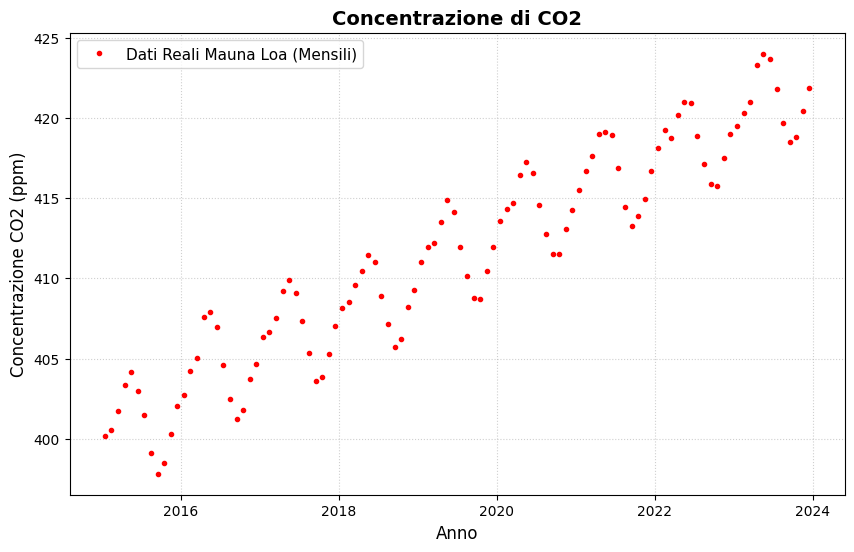

In [2]:
plt.figure(figsize=(10, 6))

plt.plot(x, y, "r.", markersize=6, label="Dati Reali Mauna Loa (Mensili)")
plt.title("Concentrazione di CO2", fontsize=14, fontweight="bold")
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Concentrazione CO2 (ppm)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper left")

plt.show()


Nei dati si individua un andamento (trend) di crescita lineare sovrapposto ad una variazione periodica che rappresenta una dipendenza della concentrazione del gas rispetto alla stagione dell'anno.

Rappresentare i dati con un modello solamente lineare (retta di regressione) porterebbe a perdere informazioni su questa caratteristica del dato che non è dovuta ad un errore di misurazione ma fa parte del fenomeno in sè.

Un modello semplice ma che tiene conto di entrambe le componenti è il seguente

$$f(x;a_0,a_1,a_2,a_3) = \underbrace{a_0 + a_1x}_{\text{Trend di crescita}} + \underbrace{a_2\sin(2\pi x) + a_3 \cos(2\pi x)}_{\text{Ciclo stagionale (periodo 1 anno)}}$$

## Approssimazione di dati con il criterio dei minimi quadrati nel caso degenere (non a rango pieno)

Il modello dei dati di Mauna Loa è un esempio del caso generale lineare, la cui forma generale è la seguente

$$f(x;a_0,a_1,...,a_{n-1}) = a_0\phi_0(x) + a_1\phi_1(x) + ...+a_{n-1}\phi_{n-1}(x) $$
dove $\phi_0,...\phi_{n-1}$ sono $n$ funzioni reali di variabile reale.

Secondo il criterio dei minimi quadrati, si definisce la funzione di distanza verticale cumulativa quadratica nel modo seguente

$$Q(a_0,a_1,...,a_{n-1}) = \sum_{i=1}^m (a_0\phi_0(x_i) + a_1\phi_1(x_i) + ...+a_{n-1}\phi_{n-1}(x_i)-y_i)^2 $$

La scelta ottimale dei parametri $a_0,a_1,...,a_{n-1}$ è quella che minimizza la funzione $Q$.

Come per i polinomi, che sono un caso particolare di questo, si introduce la matrice di regressione
$$A = \begin{pmatrix}\phi_0(x_1) &\phi_1(x_1)&\phi_2(x_1)& ... & \phi_{n-1}(x_1)\\ \phi_0(x_2) &\phi_1(x_2)&\phi_2(x_2)& ... & \phi_{n-1}(x_2)\\ \vdots&\vdots&\vdots&&\vdots \\ \phi_0(x_m) &\phi_1(x_m)&\phi_2(x_m)& ... & \phi_{n-1}(x_m) \end{pmatrix}\in {\mathbb R}^{m\times n}$$
e i vettori
$$\alpha = \begin{pmatrix} a_0\\a_1\\ \vdots \\ a_{n-1}\end{pmatrix}\in {\mathbb R}^n,\ \ \  y = \begin{pmatrix} y_1\\y_2\\ \vdots \\ y_m\end{pmatrix}\in {\mathbb R}^m$$
e si può direttamente mostrare che la funzione di distanza si può riformulare come segue
$$Q(a_0,...,a_{n-1}) = \|A\alpha-y\|^2 $$

Il problema dei minimi quadrati nel caso generale lineare richiede quindi la soluzione del problema
$$\min_{\alpha\in{\mathbb R}^n}\|A\alpha-y\|^2$$
che, almeno formalmente, è lo stesso del caso polinomiale.
La differenza principale è il fatto che, se le funzioni di base non sono i monomi, le colonne di $A$ potrebbero non essere linearmente indipendenti.
In generale, la matrice $A\in{\mathbb R}^{m\times n}$ ha rango $k$, con $k\leq n$ e il problema di minimo ha infinite soluzioni che dipendono da $n-k$ parametri.


Per individuare una soluzione del problema si utilizza l'algorimo seguente.

1. Calcolare la decomposizione SVD di A
    
    $$A = U\Sigma V^T $$
    
    dove $U\in{\mathbb R}^{m\times m}$, $V\in{\mathbb R}^{n\times n}$ sono matrici ortogonali e $\Sigma \in{\mathbb R}^{m\times n}$ è una matrice diagonale con solo $k$ elementi non nulli, i valori singolari $\sigma_1,...,\sigma_k$.

2.  Calcolare $z = U^Ty$

3. Calcolare

    $$\gamma = \begin{pmatrix} z_1/\sigma_{1}\\ \vdots\\ z_{k}/\sigma_k\\ 0\\ \vdots\\ 0\end{pmatrix}$$

4.  Calcolare $\alpha = V\gamma$.

L'output dell'algoritmo è, tra le infinite soluzioni del problema, quella che ha norma euclidea più piccola.

[Documentazione della SVD di NumPy](https://numpy.org/devdocs/reference/generated/numpy.linalg.svd.html)

In [3]:
#Definizione della matrice di regressione e della funzione-modello

def regress_matrix_gl(x,phi_list):
  m = x.size
  n = len(phi_list)
  A = np.zeros((m,n))
  for i in range(n):
    A[:,i] = phi_list[i](x)  # i-esima funzione phi calcolata sulle x
  return A

def model_gl(alpha,phi_list,xx):
  yy = np.zeros(xx.size)
  for i in range(len(phi_list)):
    yy += alpha[i]*phi_list[i](xx)
  return yy

#Implementazione dell'algoritmo di soluzione del problema di minimo

def regressione_gl(x,y,phi_list,tol):
  n = len(phi_list)
  A = regress_matrix_gl(x,phi_list)
  U, S, Vt = np.linalg.svd(A)
  # U  = Matrice Ortogonale M * N
  # S  = Primi k elementi di gamma (solo quelli non nulli)
  # Vt = Trasposta di V.
  k = np.max(np.where(S>tol))+1
  # tol  = Numero di soglia che consideriamo abbastanza piccolo (di solito 0);
  # np.where(S>tol)  = Gli indici che soddisfano la tolleranza;
  # Prendo il più grande (l'ultimo) degli indici e gli aggiungo 1.
  z = U.T@y
  gamma = np.zeros(n)
  gamma[:k] = z[:k]/S[:k]
  # Sostituisco le sue prime k componenti con la formula z_i/sigma_i
  alpha = Vt.T@gamma
  # Risoluzione del problema. Applichiamo direttamente la formula dato che T è ortogonale.
  return alpha,k,A

In [4]:
#modello per i dati di Mauna Loa
c_fun    = lambda x : 1
lin_fun  = lambda x : x
T = 2*np.pi
sin_fun  = lambda x : np.sin(T*x)
cos_fun  = lambda x : np.cos(T*x)
phi_list = [c_fun, lin_fun, sin_fun, cos_fun]


#Calcolo dei parametri ottimali
alpha,k,A = regressione_gl(x,y,phi_list,0)
print(alpha,k)

#A = regress_matrix_gl(x,phi_list)
#print(A.shape)
#beta, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
#print(beta)
#s = np.linalg.solve(A.T@A,A.T@y)
#print(s)

[-4.56481846e+03  2.46409426e+00  2.83766847e+00 -8.53817458e-01] 4


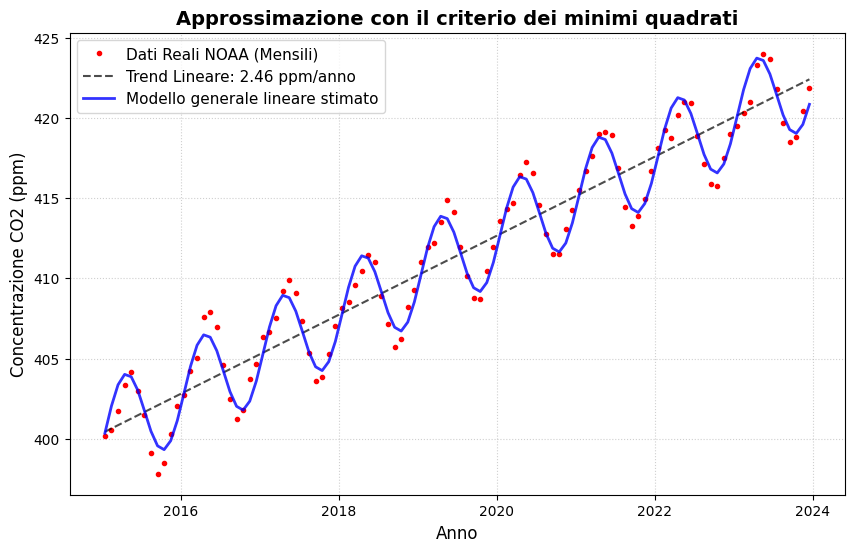

In [5]:
y_model = model_gl(alpha,phi_list,x)
y_trend = alpha[0] + alpha[1]*x

# GENERAZIONE DEL GRAFICO
plt.figure(figsize=(10, 6))

plt.plot(x, y, "r.", markersize=6, label="Dati Reali NOAA (Mensili)")
plt.plot(x, y_trend, "k--", alpha=0.7, label=f"Trend Lineare: {alpha[1]:.2f} ppm/anno")
plt.plot(x, y_model,"b-", linewidth=2, alpha=0.8, label="Modello generale lineare stimato")

plt.title( "Approssimazione con il criterio dei minimi quadrati", fontsize=14, fontweight="bold")
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Concentrazione CO2 (ppm)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper left")

plt.show()
